<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data  
y = iris.target 


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Tamanho do Treino: {len(X_train)}")
print(f"Tamanho do Teste: {len(X_test)}")

Tamanho do Treino: 105
Tamanho do Teste: 45


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf = DecisionTreeClassifier(random_state=42)

clf.fit(X_train, y_train)

y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Acurácia no Treino: {acc_train:.4f}")
print(f"Acurácia no Teste:  {acc_test:.4f}")

Acurácia no Treino: 1.0000
Acurácia no Teste:  0.9333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

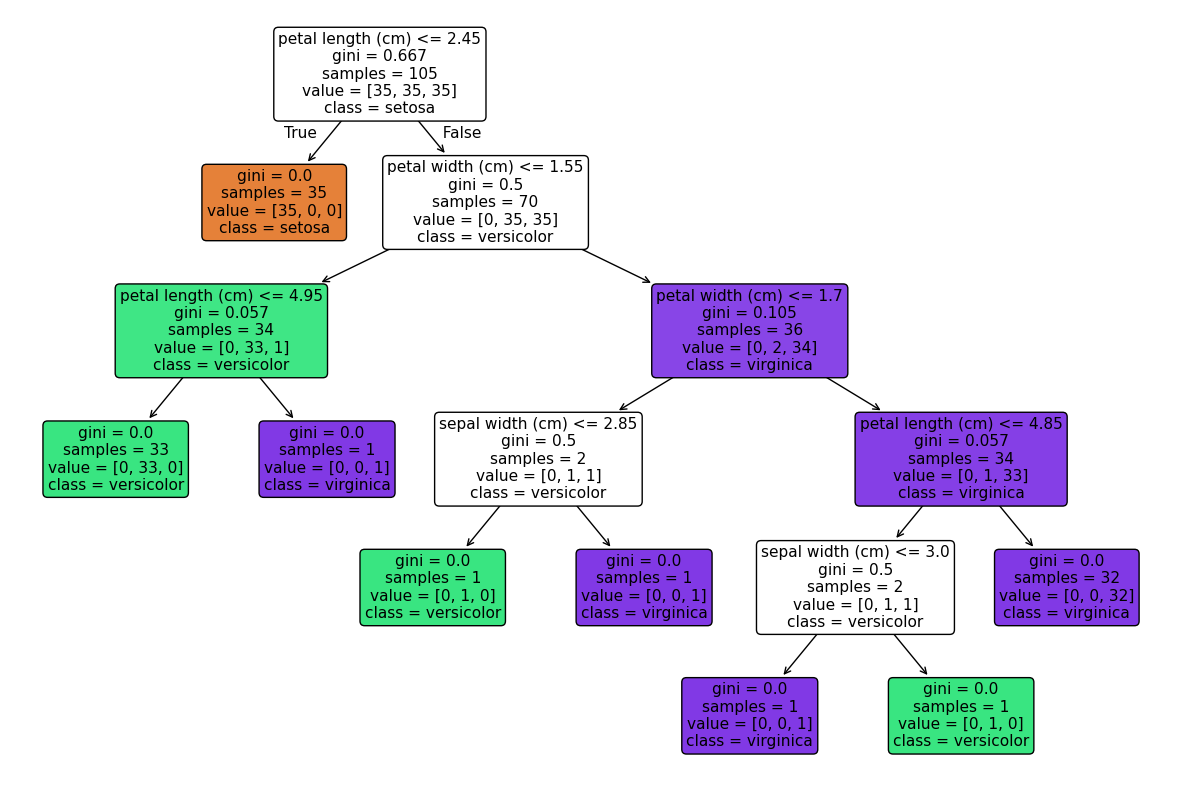

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))

plot_tree(clf, 
          feature_names=iris.feature_names, 
          class_names=iris.target_names, 
          filled=True, 
          rounded=True)

plt.show()

**1- profundidade da arvore = 5**

**2- atributo da raiz = petal_length cm'**.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [7]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, None]
resultados = []

for d in depths:
    clf_temp = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf_temp.fit(X_train, y_train)
    
    y_train_pred = clf_temp.predict(X_train)
    y_test_pred = clf_temp.predict(X_test)
    
    resultados.append({
        "Max Depth Config": "None" if d is None else d,
        "Profundidade Real": clf_temp.get_depth(),
        "Nº de Folhas": clf_temp.get_n_leaves(),
        "Acc Treino": accuracy_score(y_train, y_train_pred),
        "Acc Teste": accuracy_score(y_test, y_test_pred)
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

Max Depth Config  Profundidade Real  Nº de Folhas  Acc Treino  Acc Teste
               1                  1             2    0.666667   0.666667
               2                  2             3    0.971429   0.888889
               3                  3             5    0.980952   0.977778
               4                  4             7    0.990476   0.888889
               5                  5             8    1.000000   0.933333
               6                  5             8    1.000000   0.933333
               7                  5             8    1.000000   0.933333
               8                  5             8    1.000000   0.933333
               9                  5             8    1.000000   0.933333
            None                  5             8    1.000000   0.933333


**Na profundidade 4. a acurácia de treino sobe (0.99), mas a de teste cai drasticamente (0.88), indicando que o modelo começou a "decorar" o treino e perdeu poder de generalização.**


**Porque ela cresce sem limites até que todas as folhas sejam puras (contendo apenas uma classe), eliminando qualquer erro dentro do conjunto de treino.**

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

criterios = ["gini", "entropy"]
resultados_comp = []
for crit in criterios:
    model = DecisionTreeClassifier(criterion=crit, random_state=42)
    model.fit(X_train, y_train)
    
    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    resultados_comp.append({
        "Critério": crit,
        "Profundidade": model.get_depth(),
        "Acc Treino": accuracy_score(y_train, y_pred_train),
        "Acc Teste": accuracy_score(y_test, y_pred_test)
    })
df_comp = pd.DataFrame(resultados_comp)
print(df_comp.to_string(index=False))

Critério  Profundidade  Acc Treino  Acc Teste
    gini             5         1.0   0.933333
 entropy             6         1.0   0.888889


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [12]:
import pandas as pd
impacto_folhas = []
valores_leaf = [1, 2, 5, 10, 20, 50]
for m in valores_leaf:
    clf_leaf = DecisionTreeClassifier(min_samples_leaf=m, random_state=42)
    clf_leaf.fit(X_train, y_train)
    
    impacto_folhas.append({
        "min_samples_leaf": m,
        "treino": clf_leaf.score(X_train, y_train),
        "teste": clf_leaf.score(X_test, y_test),
        "folhas_reais": clf_leaf.get_n_leaves()
    })

df_leaf = pd.DataFrame(impacto_folhas)
melhor_idx = df_leaf['teste'].idxmax()
melhor_modelo_info = df_leaf.loc[melhor_idx]

print(df_leaf)
print("\nMelhor Modelo Encontrado")
print(f"Melhor min_samples_leaf: {melhor_modelo_info['min_samples_leaf']}")
print(f"Acurácia no Teste: {melhor_modelo_info['teste']}")

   min_samples_leaf    treino     teste  folhas_reais
0                 1  1.000000  0.933333             8
1                 2  0.971429  0.888889             6
2                 5  0.971429  0.888889             5
3                10  0.971429  0.888889             5
4                20  0.971429  0.888889             3
5                50  0.666667  0.666667             2

Melhor Modelo Encontrado
Melhor min_samples_leaf: 1.0
Acurácia no Teste: 0.9333333333333333
